<a href="https://colab.research.google.com/github/Luis-Rivadeneyra-94/TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [52]:
import pandas as pd
import numpy as np
df=pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [54]:
print(df["customerID"].nunique())
#Con nunique() vemos que los ID de los clientes no se repita, si este coincide con la cantidad de filas del DataFrame df
print(df["Churn"].nunique())
print(df["Churn"].unique())
#Vemos que hay campos vacios en los cuales no se indicad si el cliente dejó o no la empresa,
#por lo cual deberiamos indicarlo como valor nulo

7267
3
['No' 'Yes' '']


In [55]:
df["Churn"] = df["Churn"].replace("", np.nan)
print(df["Churn"].nunique())
print(df["Churn"].unique())

2
['No' 'Yes' nan]


In [56]:
customer=pd.json_normalize(df['customer'])
phone=pd.json_normalize(df['phone'])
internet=pd.json_normalize(df['internet'])
account=pd.json_normalize(df['account'])

In [57]:
##falsos_nulos = ["", " ", "null", "None", "N/A", "-"]
##account[account["Charges.Total"].isin(falsos_nulos)]

In [58]:
phone.head()

,PhoneService,MultipleLines
0,Yes,No
1,Yes,Yes
2,Yes,No
3,Yes,No
4,Yes,No


In [59]:
for x in phone.columns:
  print(phone[x].unique())

['Yes' 'No']
['No' 'Yes' 'No phone service']


In [60]:
phone = phone.replace("No phone service","No")
for x in phone.columns:
  print(phone[x].unique())

['Yes' 'No']
['No' 'Yes']


In [61]:
internet.head()

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,DSL,No,Yes,No,Yes,Yes,No
1,DSL,No,No,No,No,No,Yes
2,Fiber optic,No,No,Yes,No,No,No
3,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,Fiber optic,No,No,No,Yes,Yes,No


In [62]:
for x in internet.columns:
  print(internet[x].unique())

['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']


In [63]:
internet = internet.replace("No internet service","No")
for x in internet.columns:
  print(internet[x].unique())

['DSL' 'Fiber optic' 'No']
['No' 'Yes']
['Yes' 'No']
['No' 'Yes']
['Yes' 'No']
['Yes' 'No']
['No' 'Yes']


In [64]:
account.head()

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,One year,Yes,Mailed check,65.6,593.3
1,Month-to-month,No,Mailed check,59.9,542.4
2,Month-to-month,Yes,Electronic check,73.9,280.85
3,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Month-to-month,Yes,Mailed check,83.9,267.4


In [65]:
account.info()
#Aqui podriamos convertir el Charges.Total a float64 ya que se leyo como un object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Contract          7267 non-null   object 
 1   PaperlessBilling  7267 non-null   object 
 2   PaymentMethod     7267 non-null   object 
 3   Charges.Monthly   7267 non-null   float64
 4   Charges.Total     7267 non-null   object 
dtypes: float64(1), object(4)
memory usage: 284.0+ KB


In [66]:
account["Charges.Total"] = account["Charges.Total"].str.strip()
account["Charges.Total"] = account["Charges.Total"].replace("", np.nan)
account["Charges.Total"] = account["Charges.Total"].astype(np.float64)
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Contract          7267 non-null   object 
 1   PaperlessBilling  7267 non-null   object 
 2   PaymentMethod     7267 non-null   object 
 3   Charges.Monthly   7267 non-null   float64
 4   Charges.Total     7256 non-null   float64
dtypes: float64(2), object(3)
memory usage: 284.0+ KB


In [67]:
account[account.isnull().any(axis=1)]
#Podemos visualizar que es inconsistente ya que se tiene un gasto por mes pero no un total

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,Two year,No,Credit card (automatic),56.05,NaN
1775,Two year,No,Mailed check,20.00,NaN
1955,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,One year,Yes,Mailed check,19.70,NaN
2232,Two year,No,Mailed check,20.25,NaN
2308,Two year,No,Mailed check,25.35,NaN
2930,Two year,No,Mailed check,73.35,NaN
3134,Two year,No,Mailed check,25.75,NaN
3203,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,Two year,No,Mailed check,80.85,NaN


In [68]:
for x in account.columns:
  print(account[x].unique())

['One year' 'Month-to-month' 'Two year']
['Yes' 'No']
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
[65.6  59.9  73.9  ... 91.75 68.8  67.85]
[ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]


In [69]:
customer.head()

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3


In [70]:
for x in customer.columns:
  print(customer[x].unique())

['Female' 'Male']
[0 1]
['Yes' 'No']
['Yes' 'No']
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]


In [71]:
account["Cuentas_Diarias"]=round(account["Charges.Monthly"]/30,2)
account.head()

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,One year,Yes,Mailed check,65.6,593.30,2.19
1,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [72]:
#Consolidar en un solo DF
df_total = pd.concat([df.iloc[:, :2], customer, phone, internet, account], axis=1)
df_total.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [73]:
#Visualización de las columnas, previa al cambio de nombre para tomar de referencia
df_total.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='object')

In [74]:
df_total.columns=["Id Cliente","Permanencia del cliente","Genero","Adulto Mayor","Comprometido","Tiene dependientes","Meses de contrato","Serv. Telefonico","Más de una linea","Serv. Internet","Serv. Seguridad","Serv. Respaldo","Serv. Proteccipon","Serv. Soport tecnico menor tiempo","Serv. Televisión","Serv. Streaming","Tiempo de contacto","Factura en linea","Forma de pago","Total por mes","Total por cliente","Cuentas Diarias"]
df_total.head()

,Id Cliente,Permanencia del cliente,Genero,Adulto Mayor,Comprometido,Tiene dependientes,Meses de contrato,Serv. Telefonico,Más de una linea,Serv. Internet,...,Serv. Proteccipon,Serv. Soport tecnico menor tiempo,Serv. Televisión,Serv. Streaming,Tiempo de contacto,Factura en linea,Forma de pago,Total por mes,Total por cliente,Cuentas Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [75]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Id Cliente                         7267 non-null   object 
 1   Permanencia del cliente            7043 non-null   object 
 2   Genero                             7267 non-null   object 
 3   Adulto Mayor                       7267 non-null   int64  
 4   Comprometido                       7267 non-null   object 
 5   Tiene dependientes                 7267 non-null   object 
 6   Meses de contrato                  7267 non-null   int64  
 7   Serv. Telefonico                   7267 non-null   object 
 8   Más de una linea                   7267 non-null   object 
 9   Serv. Internet                     7267 non-null   object 
 10  Serv. Seguridad                    7267 non-null   object 
 11  Serv. Respaldo                     7267 non-null   objec

In [76]:
df_total = df_total.replace({"Yes": 1,"No": 0})
df_total["Permanencia del cliente"] = df_total["Permanencia del cliente"].astype(pd.Int64Dtype())
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Id Cliente                         7267 non-null   object 
 1   Permanencia del cliente            7043 non-null   Int64  
 2   Genero                             7267 non-null   object 
 3   Adulto Mayor                       7267 non-null   int64  
 4   Comprometido                       7267 non-null   int64  
 5   Tiene dependientes                 7267 non-null   int64  
 6   Meses de contrato                  7267 non-null   int64  
 7   Serv. Telefonico                   7267 non-null   int64  
 8   Más de una linea                   7267 non-null   int64  
 9   Serv. Internet                     7267 non-null   object 
 10  Serv. Seguridad                    7267 non-null   int64  
 11  Serv. Respaldo                     7267 non-null   int64

/tmp/ipykernel_835/821857867.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [77]:
df_total.head()

,Id Cliente,Permanencia del cliente,Genero,Adulto Mayor,Comprometido,Tiene dependientes,Meses de contrato,Serv. Telefonico,Más de una linea,Serv. Internet,...,Serv. Proteccipon,Serv. Soport tecnico menor tiempo,Serv. Televisión,Serv. Streaming,Tiempo de contacto,Factura en linea,Forma de pago,Total por mes,Total por cliente,Cuentas Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Carga y análisis

In [78]:
df_total.describe()

,Permanencia del cliente,Adulto Mayor,Comprometido,Tiene dependientes,Meses de contrato,Serv. Telefonico,Más de una linea,Serv. Seguridad,Serv. Respaldo,Serv. Proteccipon,Serv. Soport tecnico menor tiempo,Serv. Televisión,Serv. Streaming,Factura en linea,Total por mes,Total por cliente,Cuentas Diarias
count,7043.0,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.26537,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2280.634213,2.157292
std,0.441561,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.632997,1.004407
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.0,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,400.225000,1.180000
50%,0.0,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.0,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3785.300000,2.995000
max,1.0,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [79]:
permanencia = df_total.groupby("Permanencia del cliente").size().to_frame(name="Id Cliente")
permanencia= permanencia.reset_index()
permanencia["Permanencia del cliente"] = permanencia["Permanencia del cliente"].map({
    0: "No",
    1: "Sí",
})
permanencia["Porcentaje"] = round(permanencia['Id Cliente']/(permanencia['Id Cliente'].sum())*100,2)
permanencia

,Permanencia del cliente,Id Cliente,Porcentaje
0,No,5174,73.46
1,Sí,1869,26.54


In [80]:
import plotly.express as px
fig = px.bar(permanencia, x ="Permanencia del cliente",y="Id Cliente", title="Distribución de permanencia del cliente")
fig.update_layout(title_x=0.5)
fig.show()

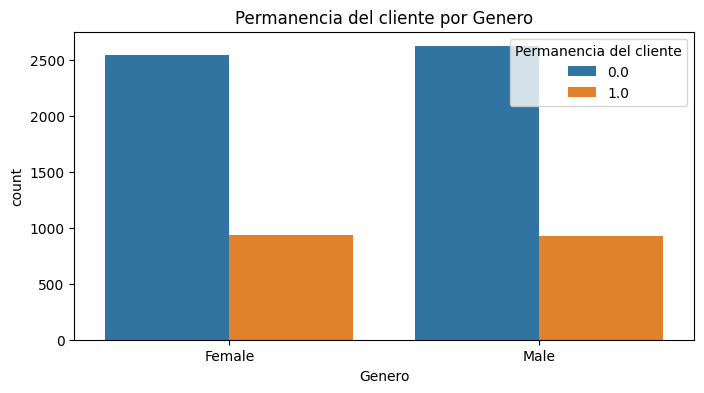

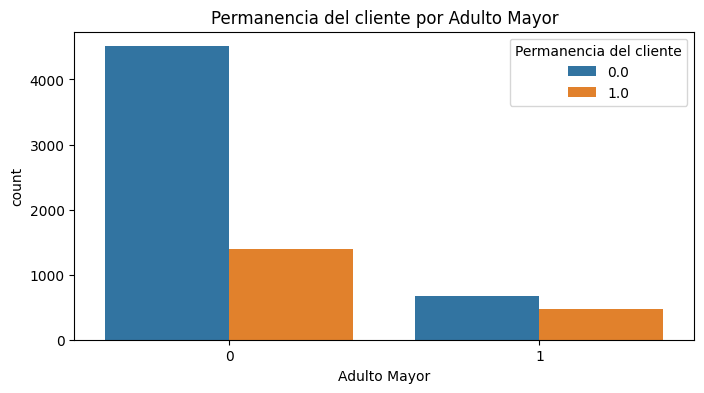

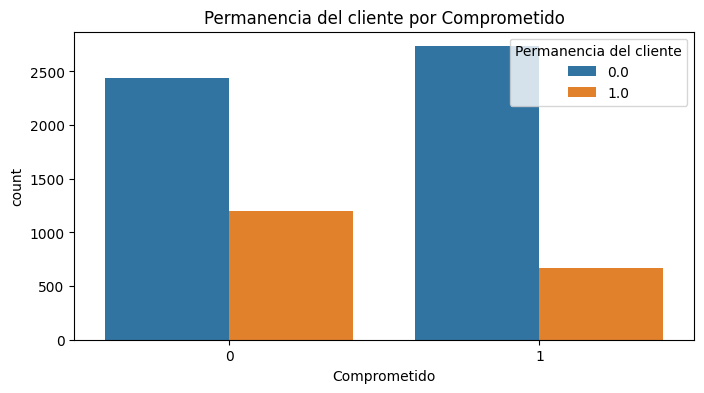

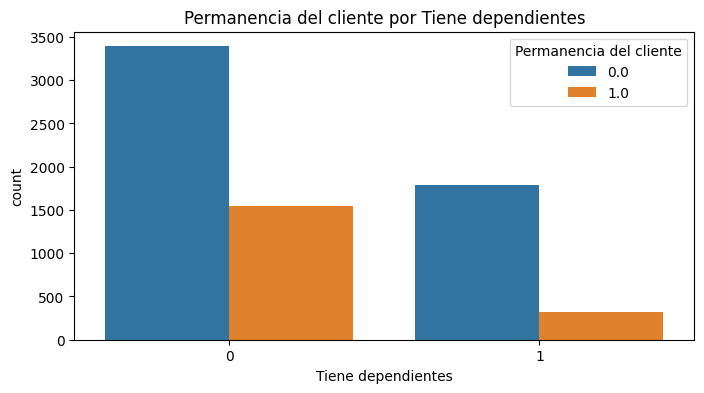

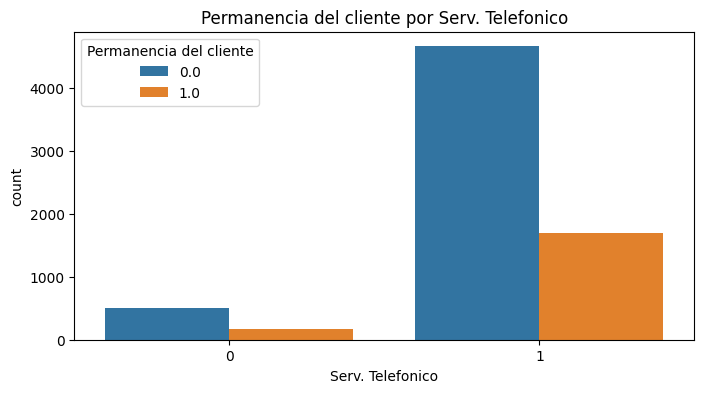

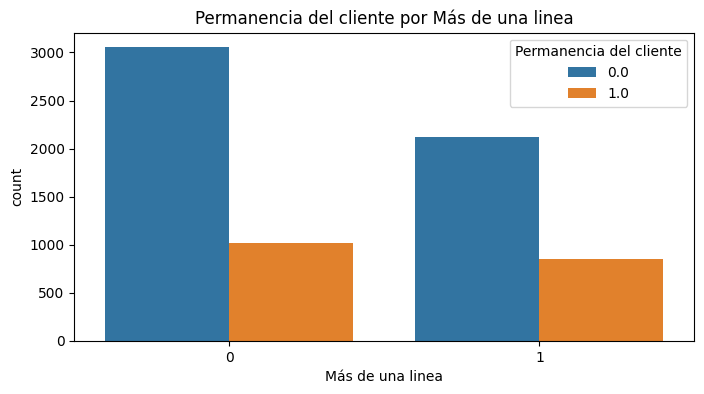

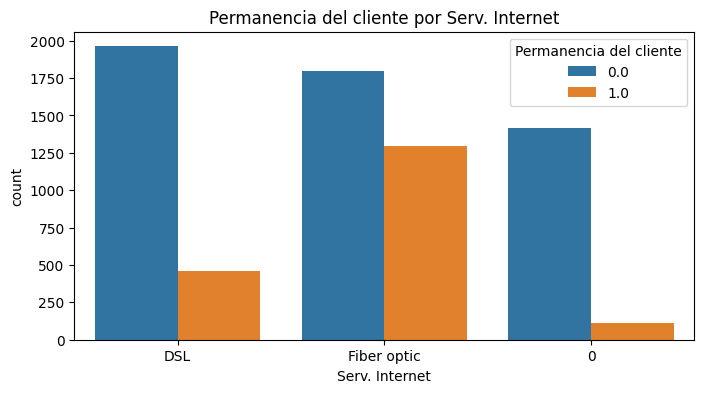

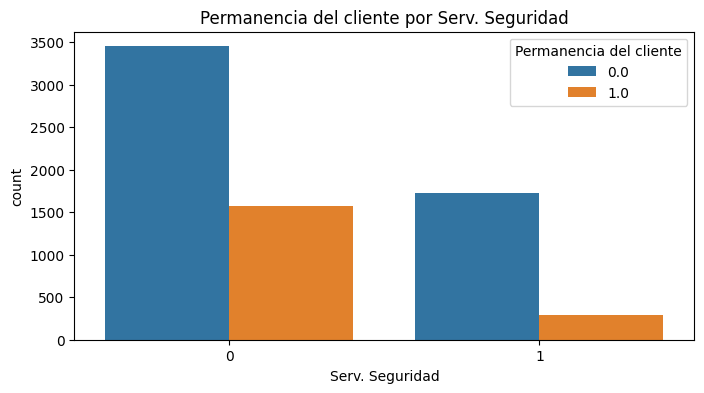

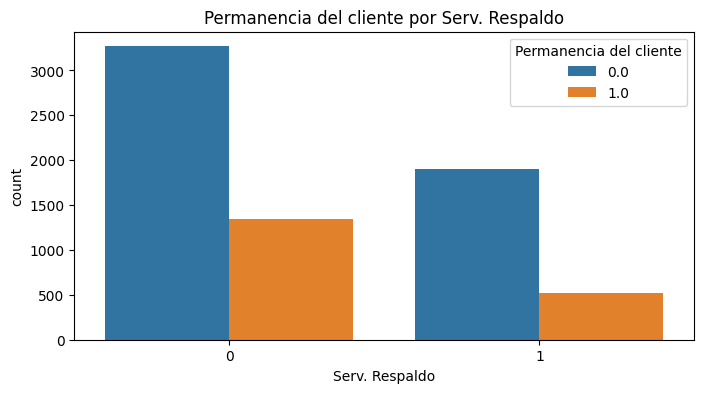

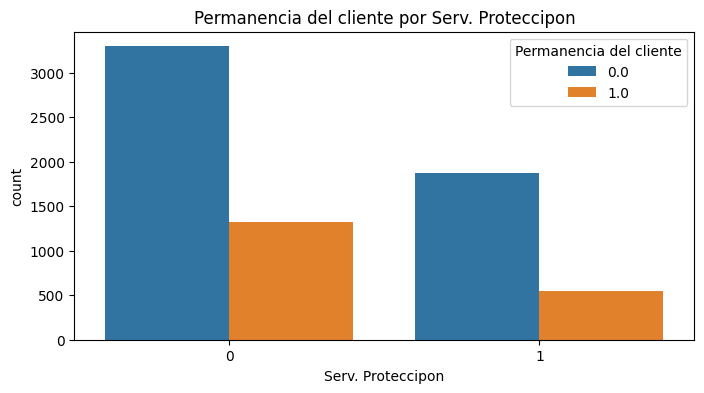

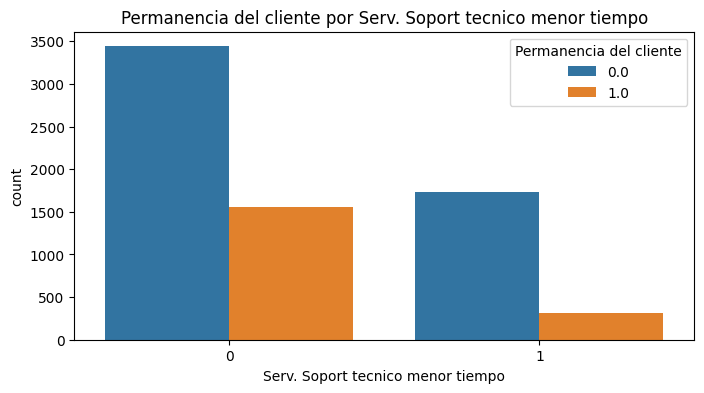

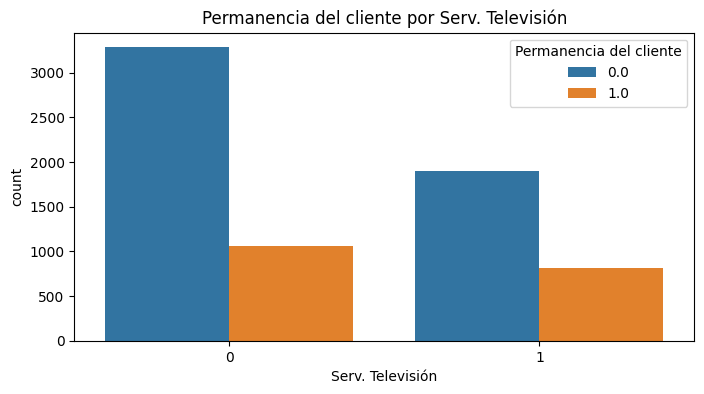

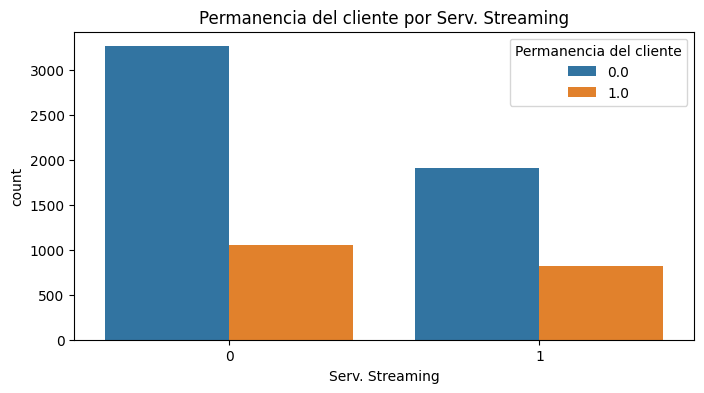

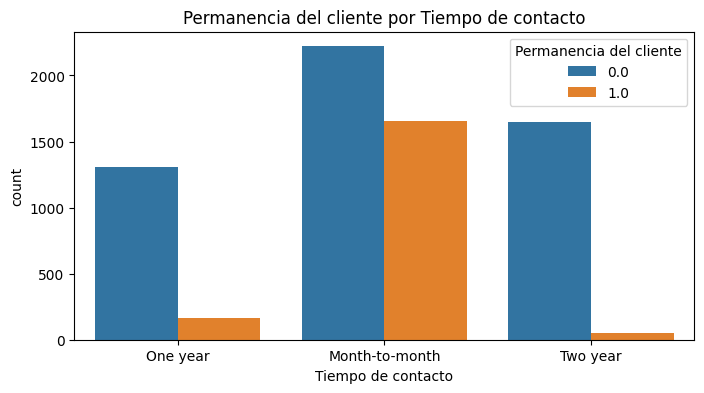

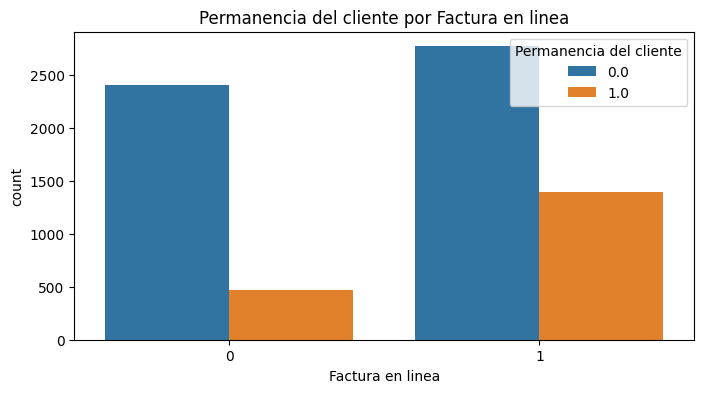

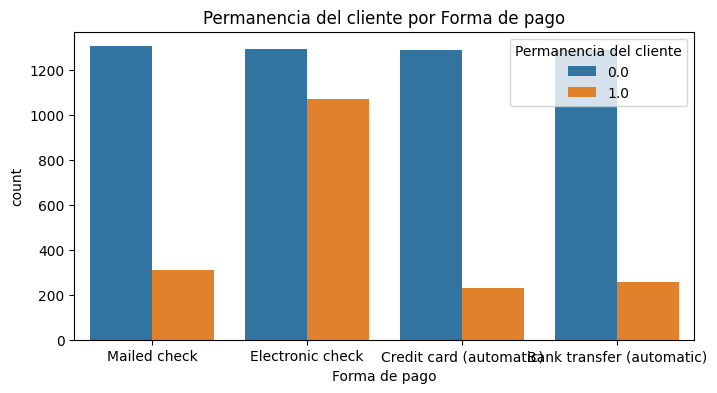

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_vars = ['Genero', 'Adulto Mayor', 'Comprometido', 'Tiene dependientes', 'Serv. Telefonico', 'Más de una linea',
            'Serv. Internet', 'Serv. Seguridad', 'Serv. Respaldo', 'Serv. Proteccipon', 'Serv. Soport tecnico menor tiempo',
            'Serv. Televisión', 'Serv. Streaming', 'Tiempo de contacto', 'Factura en linea', 'Forma de pago']
for var in cat_vars:
    plt.figure(figsize=(8,4))
    sns.countplot(x=var, hue='Permanencia del cliente', data=df_total)
    plt.title(f'Permanencia del cliente por {var}')
    plt.show()

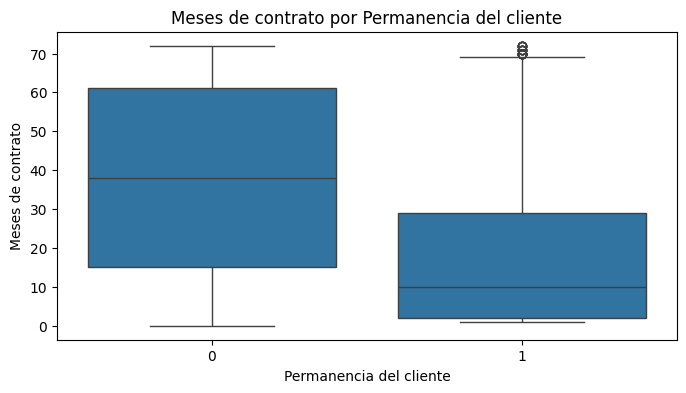

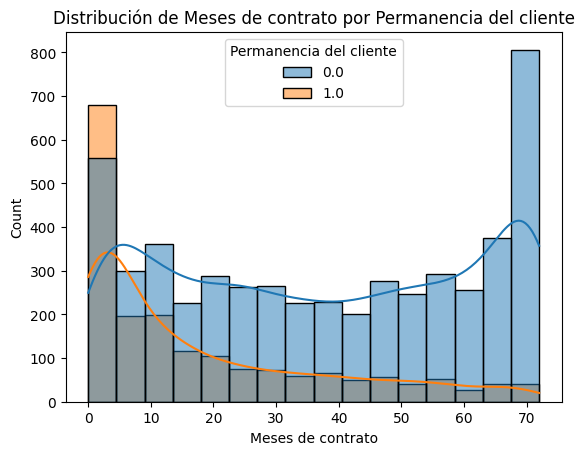

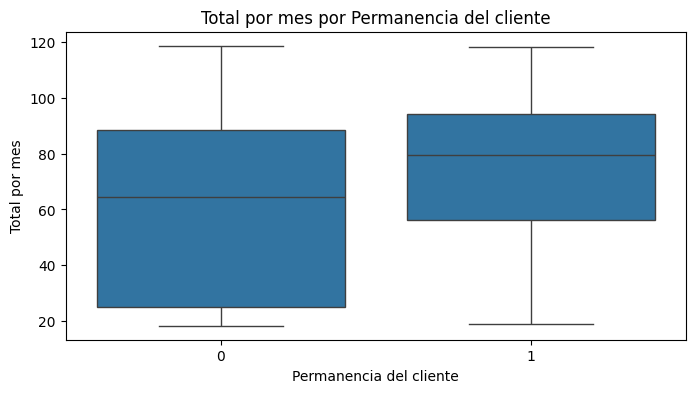

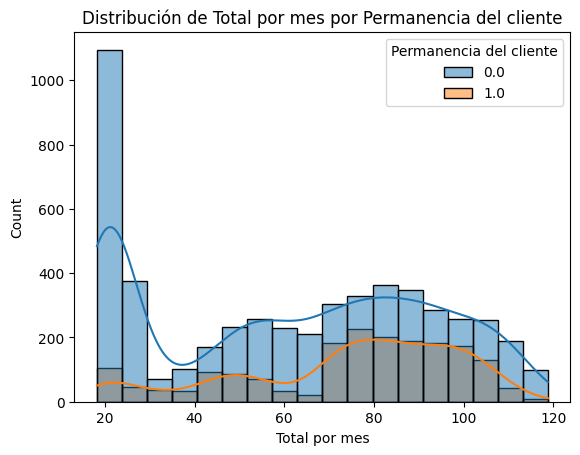

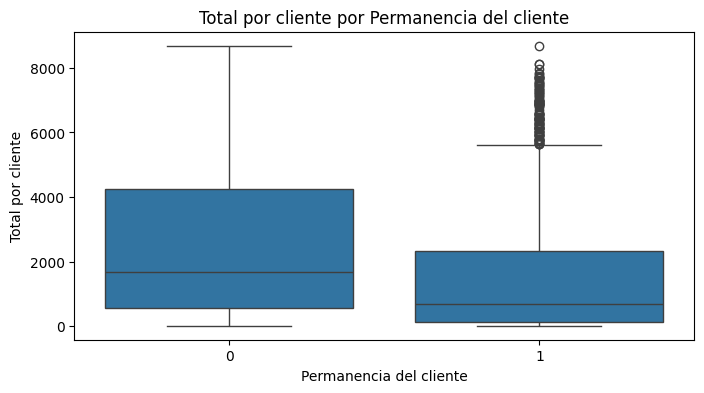

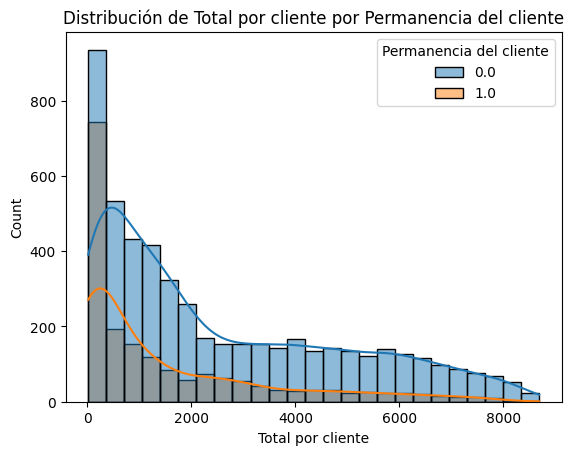

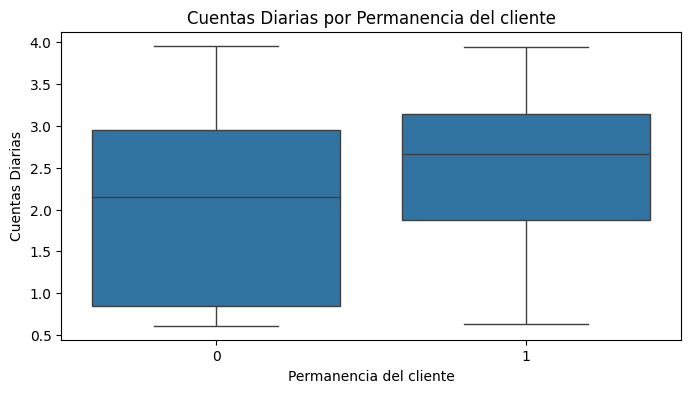

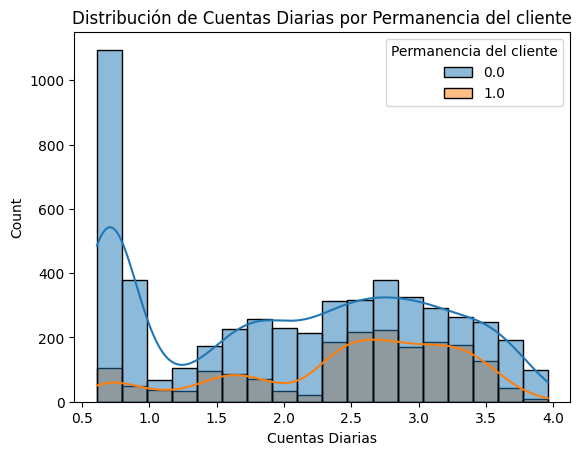

In [91]:
num_vars = ['Meses de contrato', 'Total por mes', 'Total por cliente', 'Cuentas Diarias']

for var in num_vars:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Permanencia del cliente', y=var, data=df_total)
    plt.title(f'{var} por Permanencia del cliente')
    plt.show()
    sns.histplot(data=df_total, x=var, hue='Permanencia del cliente',kde=True)
    plt.title(f'Distribución de {var} por Permanencia del cliente')
    plt.show()

#📄Informe final

**Conclusiones e insights**

La tasa de cancelación de clientes (churn) se sitúa alrededor del 26%.

Los clientes con contratos mensuales presentan una mayor probabilidad de abandono en comparación con aquellos que tienen contratos anuales.

Los métodos de pago electrónicos muestran una relación con niveles más altos de churn.

Una mayor antigüedad del cliente y mayores cargos acumulados tienden a disminuir la probabilidad de abandono.

La presencia de servicios adicionales, como el soporte técnico, contribuye a reducir el churn.

Los clientes de mayor edad y aquellos sin dependientes muestran mayor tendencia a cancelar el servicio.

**Recomendaciones**

Implementar incentivos o descuentos para promover la contratación de planes a largo plazo.

Optimizar el soporte y la atención para usuarios que utilizan métodos de pago electrónicos.

Desarrollar estrategias de fidelización dirigidas a adultos mayores y clientes recientes con poca antigüedad.

Ofrecer paquetes o bundles de servicios adicionales para aumentar la retención de clientes.

Supervisar los cargos mensuales y diarios con el fin de detectar posibles riesgos de abandono.